In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [13]:
df = pd.read_csv("customer_churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

df.drop("customerID", axis=1, inplace=True)

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

In [14]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [16]:
baseline = LogisticRegression(max_iter=1000)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.7853589196872779


In [17]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"]
}

In [18]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['lbfgs', 'liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [19]:
print("Best Parameters:")

print(grid.best_params_)

Best Parameters:
{'C': 0.1, 'solver': 'lbfgs'}


In [20]:
print(grid.best_score_)

0.8056888888888889


In [26]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "../Day19/churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [21]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, pred))

Accuracy: 0.7867803837953091


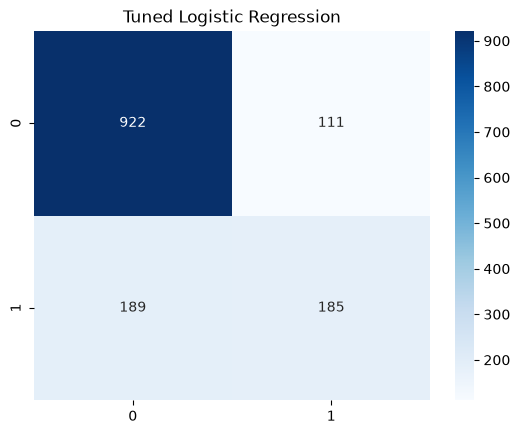

In [22]:
cm = confusion_matrix(y_test, pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Tuned Logistic Regression")

plt.show()

In [23]:
print(classification_report(
    y_test,
    pred
))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [24]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Tuned Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            baseline_pred
        ),
        accuracy_score(
            y_test,
            pred
        )
    ]
})

comparison

,Model,Accuracy
0,Baseline Logistic Regression,0.785359
1,Tuned Logistic Regression,0.786780


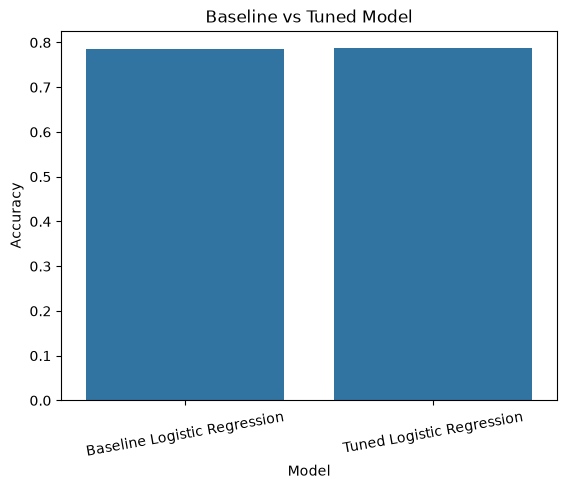

In [25]:
sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.xticks(rotation=10)

plt.title("Baseline vs Tuned Model")

plt.show()

In [27]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "churn_model.pkl")

print("Saved!")

Saved!
